In [1]:
from sklearn.datasets import load_wine, load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


diabetes_data = load_diabetes()
wine_data = load_wine()

In [2]:
def PCA_pipeline(n):
    return make_pipeline(
        StandardScaler(),
        PCA(n_components=n)
    )

In [11]:
def PCA_dataset(dataset, n):
    x, y = dataset["data"], dataset["target"]

    pca = PCA_pipeline(n)
    Z = pca.fit_transform(x)

    #print(f"Дисперсия: {pca["pca"].explained_variance_ratio_}")
    #print(f"Суммарная дисперсия: {pca["pca"].explained_variance_ratio_.sum()}")

    #match n:
    #    case 2:
    #        plt.figure(figsize=(12, 8))
    #        plt.axhline(y=0, color="gray", linestyle="-", alpha=.7)
    #        plt.axvline(x=0, color="gray", linestyle="-", alpha=.7)
    #        scatter = plt.scatter(Z[:, 0], Z[:, 1], c=y, s=50, ec="k", zorder=3)
    #        plt.xlabel("PC1")
    #        plt.ylabel("PC2")
    #        plt.colorbar(scatter)

    #    case 3:
    #        fig, ax = plt.subplots(figsize=(20, 8), subplot_kw={"projection": "3d"})
    #        scatter = ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=y, s=50, ec="k", zorder=3)
    #        ax.set_xlabel("PC1")
    #        ax.set_ylabel("PC2")
    #        ax.set_zlabel("PC3")
    #        fig.colorbar(scatter, ax=ax)

    #legend = plt.legend(*scatter.legend_elements())
    #plt.gca().add_artist(legend)
    #plt.grid(alpha=.5)
    #plt.tight_layout()
    #plt.show()

    return pca["pca"].explained_variance_ratio_.sum()

Дисперсия: [0.36198848 0.1920749 ]
Суммарная дисперсия: 0.5540633835693526


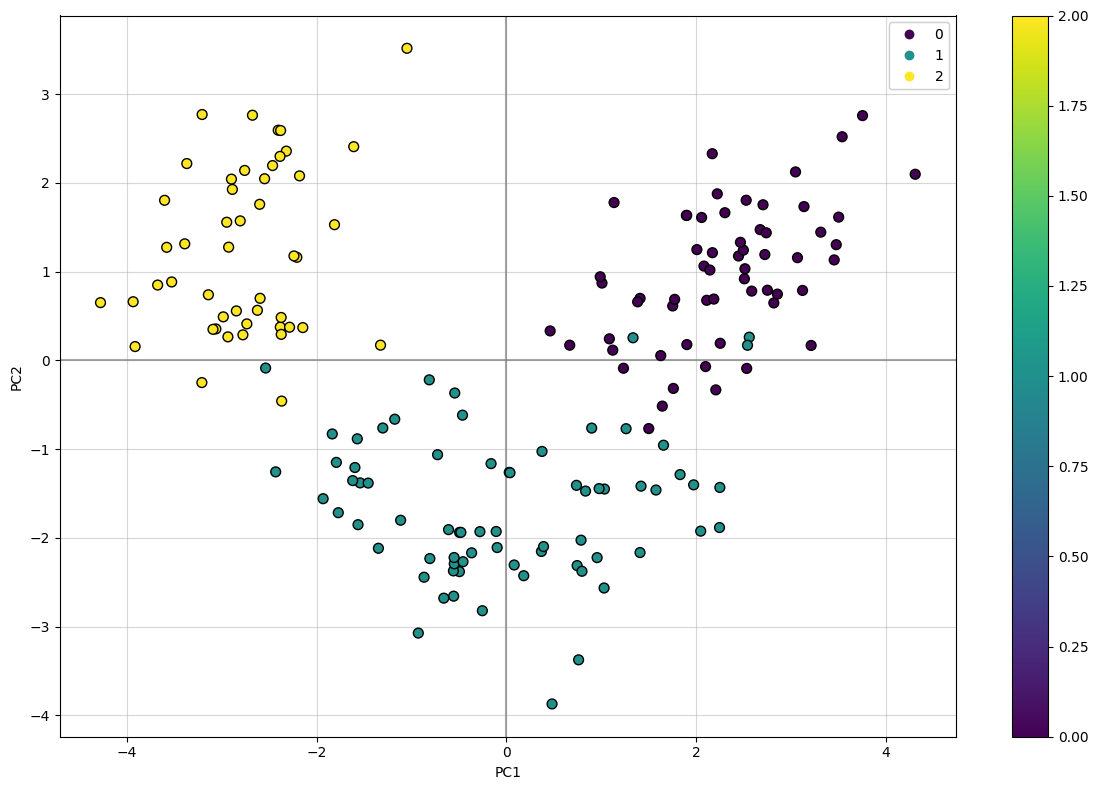

np.float64(0.5540633835693526)

In [4]:
PCA_dataset(wine_data, 2)

Дисперсия: [0.40242108 0.14923197]
Суммарная дисперсия: 0.5516530427751479


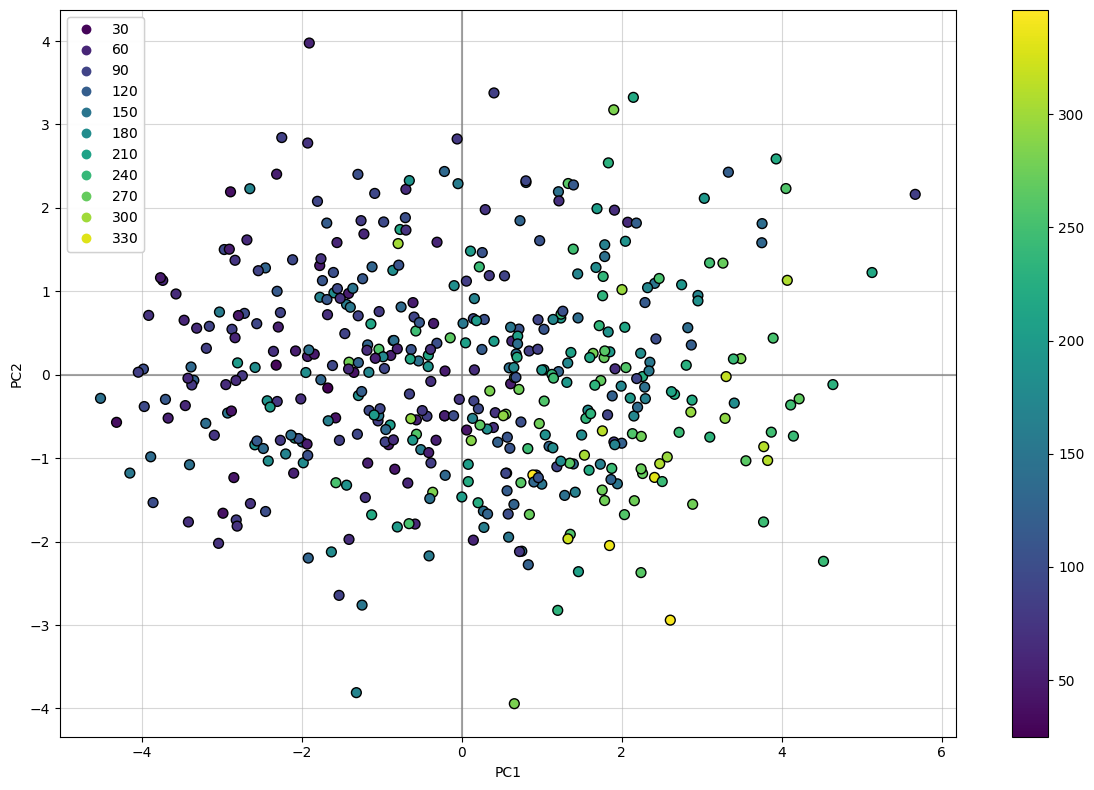

np.float64(0.5516530427751479)

In [5]:
PCA_dataset(diabetes_data, 2)

Дисперсия: [0.36198848 0.1920749  0.11123631]
Суммарная дисперсия: 0.6652996889318524


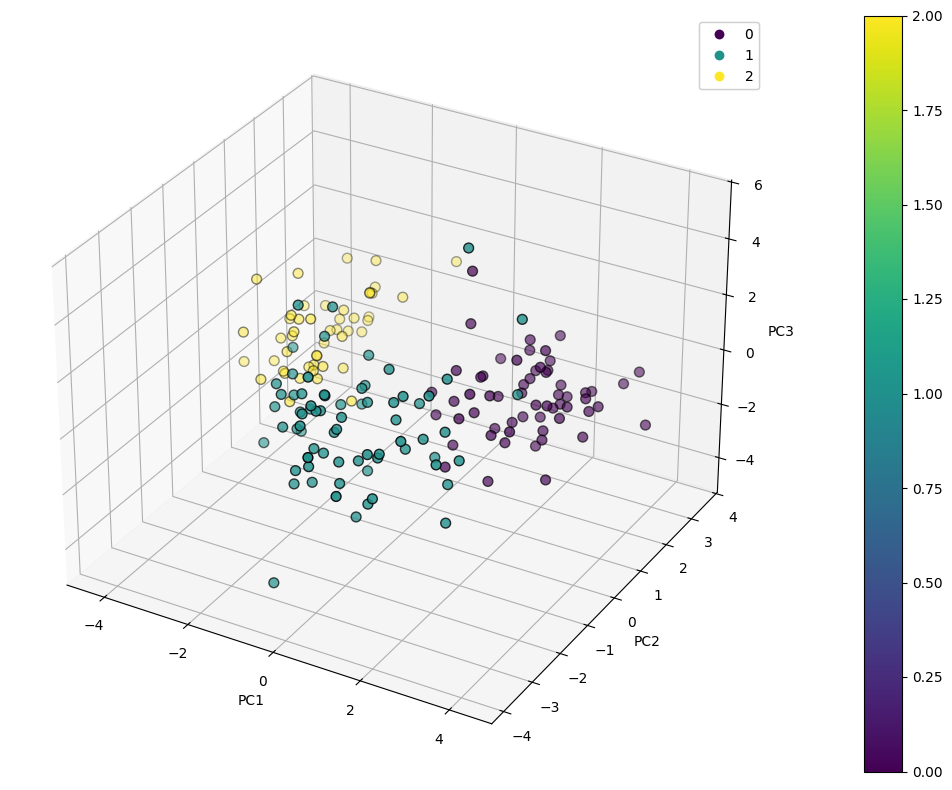

np.float64(0.6652996889318524)

In [6]:
PCA_dataset(wine_data, 3)

Дисперсия: [0.40242108 0.14923197 0.12059663]
Суммарная дисперсия: 0.6722496686876482


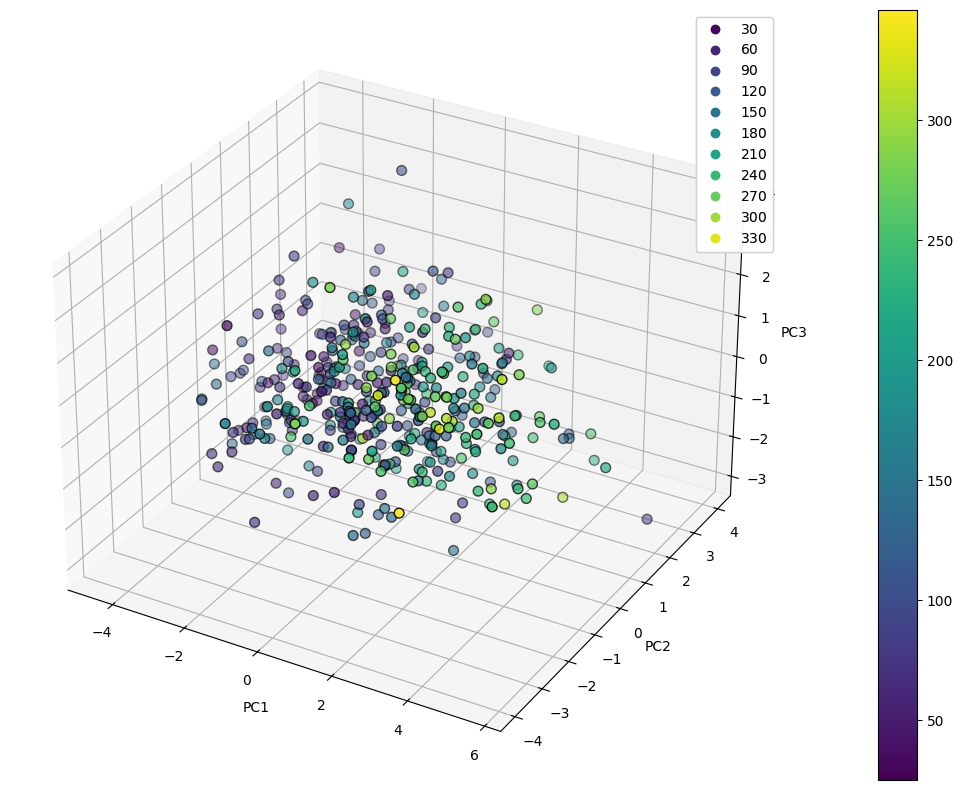

np.float64(0.6722496686876482)

In [7]:
PCA_dataset(diabetes_data, 3)

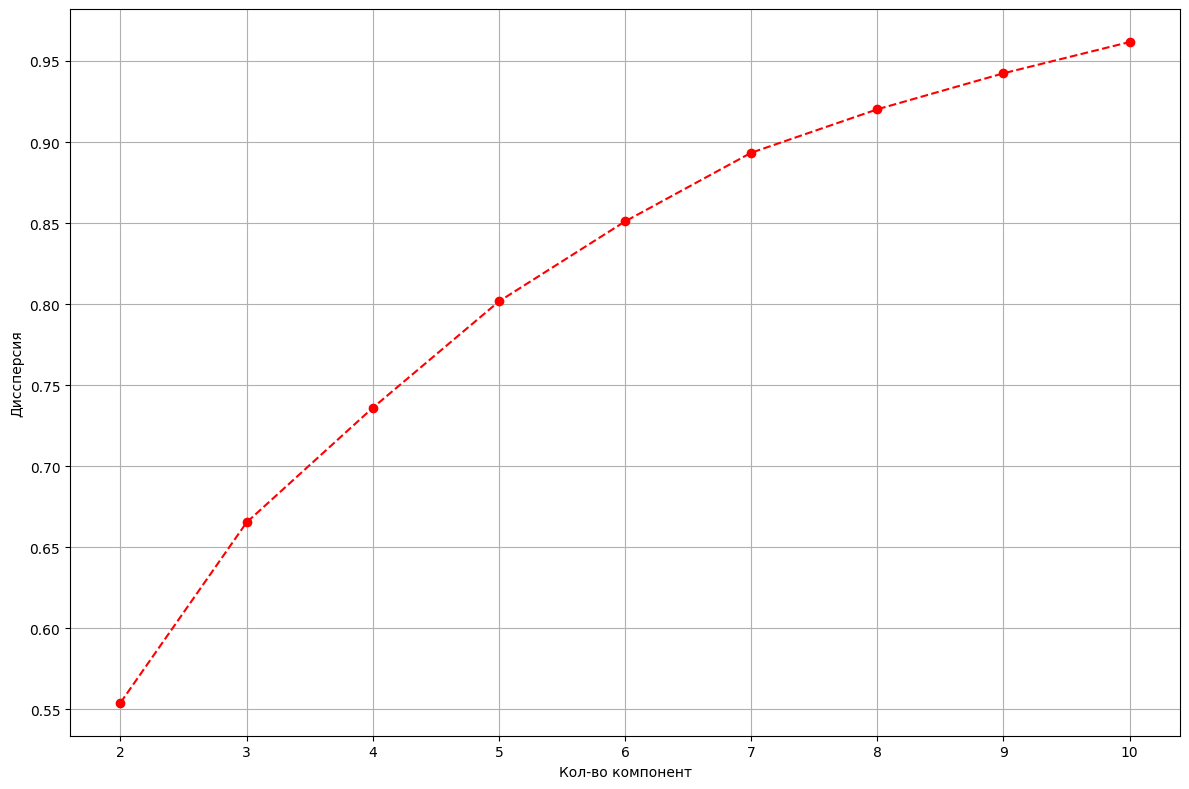

In [20]:
components = []
evr = []
for component in range(2, 11):
	components += [component]
	evr += [PCA_dataset(wine_data, component)]


plt.figure(figsize=(12, 8))

plt.plot(components, evr, "--o", c="r")
plt.xlabel("Кол-во компонент")
plt.ylabel("Диссперсия")

plt.grid()
plt.tight_layout()
plt.show()